In [4]:
# Logistic Regression for Airline Customer Satisfaction Prediction

## Project Overview
# This project analyzes passenger survey data from **Invistico Airline** to predict customer satisfaction (`satisfied` or `dissatisfied`) using **Binomial Logistic Regression**.  
# We preprocess the data, handle missing values, encode categorical features, train/test split, evaluate model performance (confusion matrix, precision, recall), and interpret coefficients to derive actionable business insights.

## Step 1: Load and Inspect the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

# Load data (assumes file is in current directory)
df = pd.read_csv('Invistico_Airline.csv')

print("Dataset shape:", df.shape)
# df.head()

Dataset shape: (129880, 22)


In [5]:
# Check missing values
print(df.isnull().sum())

# Handle missing values in delay columns (fill with 0 or median? Let's use median)
# Delay columns have numeric values, missing appear as empty strings -> convert to NaN first
df['Arrival Delay in Minutes'] = pd.to_numeric(df['Arrival Delay in Minutes'], errors='coerce')
df['Departure Delay in Minutes'] = pd.to_numeric(df['Departure Delay in Minutes'], errors='coerce')
df.fillna({'Arrival Delay in Minutes': df['Arrival Delay in Minutes'].median(),
           'Departure Delay in Minutes': df['Departure Delay in Minutes'].median()}, inplace=True)

# Drop rows with missing target (should be none)
df.dropna(subset=['satisfaction'], inplace=True)

# Encode target
df['satisfied'] = (df['satisfaction'] == 'satisfied').astype(int)

# Identify feature columns (exclude 'satisfaction' and 'satisfied')
X = df.drop(['satisfaction', 'satisfied'], axis=1)
y = df['satisfied']

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


In [6]:
# Categorical columns
cat_cols = ['Customer Type', 'Type of Travel', 'Class']

# Numerical columns (including all rating columns and delays)
num_cols = [col for col in X.columns if col not in cat_cols]

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)

Numerical features: ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical features: ['Customer Type', 'Type of Travel', 'Class']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

# Create full pipeline
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Training size: 103904
Test size: 25976


In [9]:
log_reg_pipeline.fit(X_train, y_train)

# Predictions
y_pred = log_reg_pipeline.predict(X_test)
y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['dissatisfied', 'satisfied']))

# Compute precision and recall manually
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
accuracy = (tp + tn) / (tn+fp+fn+tp)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

Confusion Matrix:
[[ 9544  2215]
 [ 2228 11989]]

Classification Report:
              precision    recall  f1-score   support

dissatisfied       0.81      0.81      0.81     11759
   satisfied       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976


Accuracy : 0.8290
Precision: 0.8441
Recall   : 0.8433
ROC AUC  : 0.9035


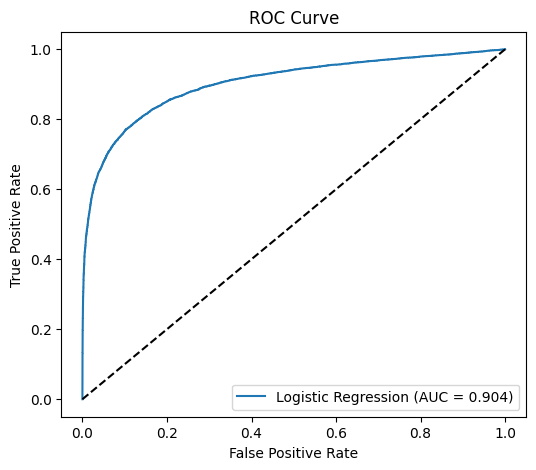

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
# Get the final model from the pipeline
model = log_reg_pipeline.named_steps['classifier']
preprocessor = log_reg_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
num_feature_names = num_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)

# Create a dataframe
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefficients,
    'odds_ratio': odds_ratios
}).sort_values('coefficient', ascending=False)

print("Top 10 positive drivers (increase satisfaction):")
print(coef_df.head(10))
print("\nTop 10 negative drivers (decrease satisfaction):")
print(coef_df.tail(10))

Top 10 positive drivers (increase satisfaction):
                   feature  coefficient  odds_ratio
7   Inflight entertainment     0.973471    2.647116
2             Seat comfort     0.391398    1.479047
10        On-board service     0.387191    1.472837
13         Checkin service     0.355213    1.426484
9   Ease of Online booking     0.333897    1.396399
11        Leg room service     0.308754    1.361728
15         Online boarding     0.181126    1.198566
5            Gate location     0.162295    1.176208
8           Online support     0.145845    1.157017
12        Baggage handling     0.109496    1.115715

Top 10 negative drivers (decrease satisfaction):
                              feature  coefficient  odds_ratio
6               Inflight wifi service    -0.127446    0.880341
0                                 Age    -0.133044    0.875427
1                     Flight Distance    -0.181292    0.834192
17           Arrival Delay in Minutes    -0.258030    0.772572
4             